# 0. Importando bibliotecas

In [409]:
pip install pandas seaborn matplotlib plotly nbformat scikit-learn --upgrade


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [410]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)

# 1. Tratamento

In [411]:
path_df_balanco_dia ="dataset_principal/balanco_servico_dia.csv"

df_balanco_dia = pd.read_csv(path_df_balanco_dia)

df_balanco_dia.head()

,data,servico,consorcio,km_apurada,receita_total_esperada,receita_tarifaria_esperada,subsidio_esperado,subsidio_glosado,receita_total_aferida,receita_tarifaria_aferida,valor_subsidio_pago,saldo,versao,datetime_ultima_atualizacao,id_execucao_dbt
0,2024-02-07,SN483,Internorte,526.046,4697.59078,2572.36494,2125.22584,2125.22584,1005.89,1005.89,0.0,-1566.47494,933971ef4769872f2b34a01c0fa8ae22488bdb85,2025-07-15 21:03:58.678701,9b1a0f21-cffb-42cf-ad0c-edf953ee336e
1,2024-02-07,313,Internorte,2839.089,25353.06477,13883.14521,11469.91956,11469.91956,17034.77,17034.77,0.0,3151.62479,933971ef4769872f2b34a01c0fa8ae22488bdb85,2025-07-15 21:03:58.678701,9b1a0f21-cffb-42cf-ad0c-edf953ee336e
2,2024-02-07,385,Internorte,119.790,1069.72470,585.77310,483.95160,483.95160,998.68,998.68,0.0,412.90690,933971ef4769872f2b34a01c0fa8ae22488bdb85,2025-07-15 21:03:58.678701,9b1a0f21-cffb-42cf-ad0c-edf953ee336e
3,2024-02-07,920,Internorte,3377.366,30159.87838,16515.31974,13644.55864,13644.55864,24611.48,24611.48,0.0,8096.16026,933971ef4769872f2b34a01c0fa8ae22488bdb85,2025-07-15 21:03:58.678701,9b1a0f21-cffb-42cf-ad0c-edf953ee336e
4,2024-02-07,249,Internorte,5411.151,48321.57843,26460.52839,21861.05004,21861.05004,53311.40,53311.40,0.0,26850.87161,933971ef4769872f2b34a01c0fa8ae22488bdb85,2025-07-15 21:03:58.678701,9b1a0f21-cffb-42cf-ad0c-edf953ee336e


In [412]:
df_balanco_dia_tratado = df_balanco_dia.drop(columns=['km_apurada','versao','datetime_ultima_atualizacao','id_execucao_dbt'])
df_balanco_dia_tratado.head()

,data,servico,consorcio,receita_total_esperada,receita_tarifaria_esperada,subsidio_esperado,subsidio_glosado,receita_total_aferida,receita_tarifaria_aferida,valor_subsidio_pago,saldo
0,2024-02-07,SN483,Internorte,4697.59078,2572.36494,2125.22584,2125.22584,1005.89,1005.89,0.0,-1566.47494
1,2024-02-07,313,Internorte,25353.06477,13883.14521,11469.91956,11469.91956,17034.77,17034.77,0.0,3151.62479
2,2024-02-07,385,Internorte,1069.72470,585.77310,483.95160,483.95160,998.68,998.68,0.0,412.90690
3,2024-02-07,920,Internorte,30159.87838,16515.31974,13644.55864,13644.55864,24611.48,24611.48,0.0,8096.16026
4,2024-02-07,249,Internorte,48321.57843,26460.52839,21861.05004,21861.05004,53311.40,53311.40,0.0,26850.87161


In [413]:
path_df_servico_historico = "dataset_principal/sumario_servico_dia_historico.csv"

df_servico_historico = pd.read_csv(path_df_servico_historico)

df_servico_historico.head()

,data,tipo_dia,consorcio,servico,vista,viagens,km_apurada,km_planejada,perc_km_planejada,valor_subsidio_pago,valor_penalidade,datetime_ultima_atualizacao
0,2024-04-06,Sabado,Santa Cruz,383,Realengo - Praça da República,154,5154.242,6056.38,85.10,14980.27260,0.0,2025-09-22 12:32:31.291432
1,2024-04-06,Sabado,Santa Cruz,SN898,Sepetiba - Campo Grande,14,438.038,377.51,116.03,1769.67352,0.0,2025-09-22 12:32:31.291432
2,2024-04-06,Sabado,Santa Cruz,853,Vila Kennedy - Terminal Mato Alto,72,1738.368,1786.66,97.30,7023.00672,0.0,2025-09-22 12:32:31.291432
3,2024-04-06,Sabado,Santa Cruz,SN885,Terminal Mato Alto - Santa Cruz,17,297.490,279.71,106.36,990.32740,0.0,2025-09-22 12:32:31.291432
4,2024-04-06,Sabado,Santa Cruz,845,Cantagalo - Terminal Campo Grande,38,265.620,231.10,114.94,1073.10480,0.0,2025-09-22 12:32:31.291432


In [414]:
df_servico_historico[['bairro_inicio', 'bairro_fim']] = df_servico_historico['vista'].str.split('-', expand=True)
df_servico_historico_tratado = df_servico_historico.drop(columns=['datetime_ultima_atualizacao','valor_subsidio_pago','vista'])


In [415]:
df_final = df_servico_historico_tratado.merge(df_balanco_dia_tratado, on=['servico', 'data','consorcio'], how='inner')

In [416]:
df_final.head()

,data,tipo_dia,consorcio,servico,viagens,km_apurada,km_planejada,perc_km_planejada,valor_penalidade,bairro_inicio,bairro_fim,receita_total_esperada,receita_tarifaria_esperada,subsidio_esperado,subsidio_glosado,receita_total_aferida,receita_tarifaria_aferida,valor_subsidio_pago,saldo
0,2024-04-06,Sabado,Santa Cruz,383,154,5154.242,6056.38,85.10,0.0,Realengo,Praça da República,46027.38106,25204.24338,20823.13768,5842.86508,39321.03260,24340.76,14980.27260,-863.48338
1,2024-04-06,Sabado,Santa Cruz,SN898,14,438.038,377.51,116.03,0.0,Sepetiba,Campo Grande,3911.67934,2142.00582,1769.67352,0.00000,2332.97352,563.30,1769.67352,-1578.70582
2,2024-04-06,Sabado,Santa Cruz,853,72,1738.368,1786.66,97.30,0.0,Vila Kennedy,Terminal Mato Alto,15523.62624,8500.61952,7023.00672,0.00000,13869.00672,6846.00,7023.00672,-1654.61952
3,2024-04-06,Sabado,Santa Cruz,SN885,17,297.490,279.71,106.36,0.0,Terminal Mato Alto,Santa Cruz,2656.58570,1454.72610,1201.85960,211.53220,1370.44740,380.12,990.32740,-1074.60610
4,2024-04-06,Sabado,Santa Cruz,845,38,265.620,231.10,114.94,0.0,Cantagalo,Terminal Campo Grande,2371.98660,1298.88180,1073.10480,0.00000,1488.15480,415.05,1073.10480,-883.83180


In [417]:
# Reorganizando as colunas para melhorar a leitura

col = df_final.pop('bairro_inicio')
df_final.insert(4, 'bairro_inicio', col)

col = df_final.pop('bairro_fim')
df_final.insert(5, 'bairro_fim', col)


In [418]:
df_final.head()

,data,tipo_dia,consorcio,servico,bairro_inicio,bairro_fim,viagens,km_apurada,km_planejada,perc_km_planejada,valor_penalidade,receita_total_esperada,receita_tarifaria_esperada,subsidio_esperado,subsidio_glosado,receita_total_aferida,receita_tarifaria_aferida,valor_subsidio_pago,saldo
0,2024-04-06,Sabado,Santa Cruz,383,Realengo,Praça da República,154,5154.242,6056.38,85.10,0.0,46027.38106,25204.24338,20823.13768,5842.86508,39321.03260,24340.76,14980.27260,-863.48338
1,2024-04-06,Sabado,Santa Cruz,SN898,Sepetiba,Campo Grande,14,438.038,377.51,116.03,0.0,3911.67934,2142.00582,1769.67352,0.00000,2332.97352,563.30,1769.67352,-1578.70582
2,2024-04-06,Sabado,Santa Cruz,853,Vila Kennedy,Terminal Mato Alto,72,1738.368,1786.66,97.30,0.0,15523.62624,8500.61952,7023.00672,0.00000,13869.00672,6846.00,7023.00672,-1654.61952
3,2024-04-06,Sabado,Santa Cruz,SN885,Terminal Mato Alto,Santa Cruz,17,297.490,279.71,106.36,0.0,2656.58570,1454.72610,1201.85960,211.53220,1370.44740,380.12,990.32740,-1074.60610
4,2024-04-06,Sabado,Santa Cruz,845,Cantagalo,Terminal Campo Grande,38,265.620,231.10,114.94,0.0,2371.98660,1298.88180,1073.10480,0.00000,1488.15480,415.05,1073.10480,-883.83180


In [419]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 60143 entries, 0 to 60142
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   data                        60143 non-null  str    
 1   tipo_dia                    60143 non-null  str    
 2   consorcio                   60143 non-null  str    
 3   servico                     60143 non-null  str    
 4   bairro_inicio               60143 non-null  str    
 5   bairro_fim                  60143 non-null  str    
 6   viagens                     60143 non-null  int64  
 7   km_apurada                  60143 non-null  float64
 8   km_planejada                60143 non-null  float64
 9   perc_km_planejada           60143 non-null  float64
 10  valor_penalidade            60143 non-null  float64
 11  receita_total_esperada      59771 non-null  float64
 12  receita_tarifaria_esperada  60143 non-null  float64
 13  subsidio_esperado           59771 non-null

### 1.1 Tratamento de nulos

In [420]:
df_final[df_final.isnull().any(axis=1)]

,data,tipo_dia,consorcio,servico,bairro_inicio,bairro_fim,viagens,km_apurada,km_planejada,perc_km_planejada,valor_penalidade,receita_total_esperada,receita_tarifaria_esperada,subsidio_esperado,subsidio_glosado,receita_total_aferida,receita_tarifaria_aferida,valor_subsidio_pago,saldo
40777,2024-08-16,Dia Útil,Intersul,110,Terminal Gentileza,Jardim de Alah,210,3194.988,3679.61,86.83,0.0,NaN,15623.49132,NaN,NaN,NaN,22038.14,NaN,6414.64868
40778,2024-08-16,Dia Útil,Intersul,448,Furnas,São Conrado,34,437.954,463.72,94.44,0.0,NaN,2141.59506,NaN,NaN,NaN,1822.13,NaN,-319.46506
40779,2024-08-16,Dia Útil,Intersul,LECD96,Metrô Botafogo,Terminal Alvorada,262,6064.908,5833.80,103.96,0.0,NaN,29657.40012,NaN,NaN,NaN,45948.76,NaN,16291.35988
40780,2024-08-16,Dia Útil,Intersul,472,Triagem,Leme,138,3002.880,2828.80,106.15,0.0,NaN,14575.33938,NaN,NaN,NaN,15744.03,NaN,1168.69062
40781,2024-08-16,Dia Útil,Intersul,461,São Cristóvão,Ipanema,116,3080.032,3425.21,89.92,0.0,NaN,15061.35648,NaN,NaN,NaN,17873.47,NaN,2812.11352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41144,2024-08-16,Dia Útil,Santa Cruz,866,Terminal Campo Grande,Pedra de Guaratiba,56,2274.832,2274.83,100.00,0.0,NaN,11123.92848,NaN,NaN,NaN,10969.30,NaN,-154.62848
41145,2024-08-16,Dia Útil,Transcarioca,SN954,Terminal Taquara,Recreio dos Bandeirantes,9,194.127,173.08,112.16,0.0,NaN,949.28103,NaN,NaN,NaN,223.24,NaN,-726.04103
41146,2024-08-16,Dia Útil,Transcarioca,954,Terminal Taquara,Recreio dos Bandeirantes,209,4522.402,4413.64,102.46,0.0,NaN,21902.95059,NaN,NaN,NaN,32149.72,NaN,10246.76941
41147,2024-08-16,Dia Útil,Santa Cruz,SV866,Terminal Campo Grande,Terminal Pingo d'Água,63,1198.309,1216.67,98.49,0.0,NaN,5859.73101,NaN,NaN,NaN,6660.95,NaN,801.21899


In [421]:
df_final = df_final.dropna().reset_index(drop=True)

In [422]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 59771 entries, 0 to 59770
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   data                        59771 non-null  str    
 1   tipo_dia                    59771 non-null  str    
 2   consorcio                   59771 non-null  str    
 3   servico                     59771 non-null  str    
 4   bairro_inicio               59771 non-null  str    
 5   bairro_fim                  59771 non-null  str    
 6   viagens                     59771 non-null  int64  
 7   km_apurada                  59771 non-null  float64
 8   km_planejada                59771 non-null  float64
 9   perc_km_planejada           59771 non-null  float64
 10  valor_penalidade            59771 non-null  float64
 11  receita_total_esperada      59771 non-null  float64
 12  receita_tarifaria_esperada  59771 non-null  float64
 13  subsidio_esperado           59771 non-null

# 2. Análise gráfica dos dados

In [423]:
# Calcula o total do saldo por serviço
total_balanco = df_final.groupby('servico')['saldo'].sum()

# Pega os índices dos 5 maiores serviços lucrativos
top5 = total_balanco.nlargest(5).index

# Pega os índices dos 5 maiores serviços que dão prejuízo 
worst5 = total_balanco.nsmallest(5).index

# Cria uma lista com os 5 mais lucrativos e 5 desvantajosos
selecionar_servicos = list(top5) + list(worst5)

# Filtra o dataset apenas para mostrar esses serviços
df_final_melhores_piores = df_final[df_final['servico'].isin(selecionar_servicos)].groupby('servico', as_index = False)['saldo'].mean()

# Ordenando
df_final_melhores_piores = df_final_melhores_piores.sort_values(by='saldo', ascending=False)

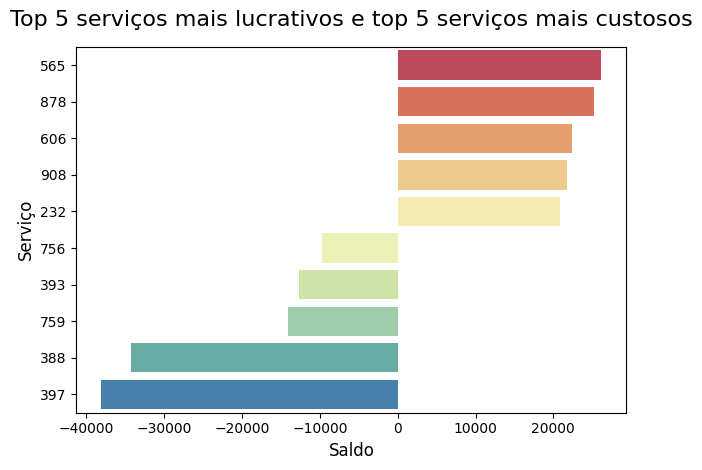

In [424]:
ax = sns.barplot(
    data=df_final_melhores_piores,
    x="saldo",
    y="servico",
    palette = 'Spectral',
    hue="servico"
)

plt.title("Top 5 serviços mais lucrativos e top 5 serviços mais custosos", fontsize=16, pad=15)
plt.xlabel("Saldo", fontsize=12)
plt.ylabel("Serviço", fontsize=12)

plt.tight_layout()
plt.show()

In [425]:
# Calcula o total do saldo por serviço
df_final_maiores_subsidios_glosados = df_final.groupby('servico')['subsidio_glosado'].sum()

# Pega os 5 maiores serviços
top20 = df_final_maiores_subsidios_glosados.nlargest(20).index

# Converte para lista
selecionar_servicos = list(top20)

# Filtra o dataset apenas para mostrar esses serviços
df_final_maiores_subsidios_glosados =  df_final[df_final['servico'].isin(selecionar_servicos)].groupby('servico', as_index=False)['subsidio_glosado'].sum()

# Colocar em ordem decrescente
df_final_maiores_subsidios_glosados= df_final_maiores_subsidios_glosados.sort_values(by='subsidio_glosado', ascending = False)


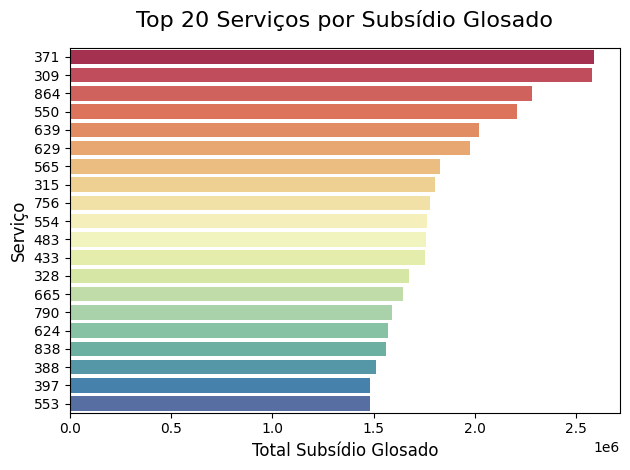

In [426]:
ax = sns.barplot(
    data=df_final_maiores_subsidios_glosados,
    x="subsidio_glosado",
    y="servico",
    palette = 'Spectral',
    hue="servico"
)

plt.title("Top 20 Serviços por Subsídio Glosado", fontsize=16, pad=15)
plt.xlabel("Total Subsídio Glosado", fontsize=12)
plt.ylabel("Serviço", fontsize=12)

plt.tight_layout()
plt.show()

In [427]:
print(df_final['servico'].nunique())

438


### 2.1 Verificar se linhas fantasmas foram contabilizadas nos dados

fonte: https://extra.globo.com/noticias/rio/moradores-sofrem-com-onibus-fantasmas-na-zona-oeste-rv1-1-23836888.html

In [428]:
linhas_fantasmas_2019 = ['358','365','366','388','395','398','364','389','739','744','751','767','874','933']

for servico in linhas_fantasmas_2019:
    if(servico in df_final['servico'].values):
        print(servico)

388
395
389


Dado que o serviço 388 é listado no gráfico de maiores subsídios glosados, ou seja, ele é um dos top 20 dentre 438 serviços, e há relatos de 2019 que esse serviço operava como linha fantasma, é bem provável que essa linha não tenha melhorado até o período de 2024-2025, e possívelmente até hoje, atuando como um serviço fraudulento para tentativa de captar subsídios.

### 2.2 Verificar a lucratividade por dia da semana

In [429]:
# Calcula o total do saldo por serviço
df_dia_balanco = df_final.groupby('tipo_dia', as_index= False)['saldo'].mean()

# Ordenando
df_dia_balanco = df_dia_balanco.sort_values(by='saldo', ascending=False)

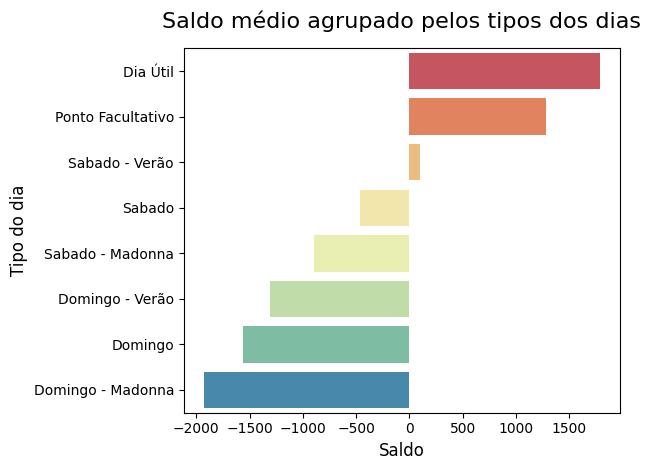

In [430]:
ax = sns.barplot(
    data=df_dia_balanco,
    x="saldo",
    y="tipo_dia",
    palette = 'Spectral',
    hue="tipo_dia"
)

plt.title("Saldo médio agrupado pelos tipos dos dias", fontsize=16, pad=15)
plt.xlabel("Saldo", fontsize=12)
plt.ylabel("Tipo do dia", fontsize=12)

plt.tight_layout()
plt.show()

# 3. Pré-processamento

In [431]:
df_ml = df_final
df_ml.head()

,data,tipo_dia,consorcio,servico,bairro_inicio,bairro_fim,viagens,km_apurada,km_planejada,perc_km_planejada,valor_penalidade,receita_total_esperada,receita_tarifaria_esperada,subsidio_esperado,subsidio_glosado,receita_total_aferida,receita_tarifaria_aferida,valor_subsidio_pago,saldo
0,2024-04-06,Sabado,Santa Cruz,383,Realengo,Praça da República,154,5154.242,6056.38,85.10,0.0,46027.38106,25204.24338,20823.13768,5842.86508,39321.03260,24340.76,14980.27260,-863.48338
1,2024-04-06,Sabado,Santa Cruz,SN898,Sepetiba,Campo Grande,14,438.038,377.51,116.03,0.0,3911.67934,2142.00582,1769.67352,0.00000,2332.97352,563.30,1769.67352,-1578.70582
2,2024-04-06,Sabado,Santa Cruz,853,Vila Kennedy,Terminal Mato Alto,72,1738.368,1786.66,97.30,0.0,15523.62624,8500.61952,7023.00672,0.00000,13869.00672,6846.00,7023.00672,-1654.61952
3,2024-04-06,Sabado,Santa Cruz,SN885,Terminal Mato Alto,Santa Cruz,17,297.490,279.71,106.36,0.0,2656.58570,1454.72610,1201.85960,211.53220,1370.44740,380.12,990.32740,-1074.60610
4,2024-04-06,Sabado,Santa Cruz,845,Cantagalo,Terminal Campo Grande,38,265.620,231.10,114.94,0.0,2371.98660,1298.88180,1073.10480,0.00000,1488.15480,415.05,1073.10480,-883.83180


In [432]:
# Seleção inicial de features (Remoção de variáveis que não fazem sentido para o treinamento)

df_ml = df_ml[['tipo_dia','bairro_inicio','bairro_fim','viagens','km_apurada','km_planejada','perc_km_planejada','saldo']]

df_ml.head()

,tipo_dia,bairro_inicio,bairro_fim,viagens,km_apurada,km_planejada,perc_km_planejada,saldo
0,Sabado,Realengo,Praça da República,154,5154.242,6056.38,85.10,-863.48338
1,Sabado,Sepetiba,Campo Grande,14,438.038,377.51,116.03,-1578.70582
2,Sabado,Vila Kennedy,Terminal Mato Alto,72,1738.368,1786.66,97.30,-1654.61952
3,Sabado,Terminal Mato Alto,Santa Cruz,17,297.490,279.71,106.36,-1074.60610
4,Sabado,Cantagalo,Terminal Campo Grande,38,265.620,231.10,114.94,-883.83180


### 3.1 One-hot-encoding

Código para transformar variáveis categóricas em numéricas utilizando o one-hot-encoding. No caso do bairro, como são muitos, a matrix ficaria muito esparsa, então foi feito um tratamento adicional para transformar os bairros para regiões.

In [433]:
# Transformando variáveis categóricas em numéricas
encoder = OneHotEncoder(sparse_output=False)

encoded_array = encoder.fit_transform(df_ml[['tipo_dia']])


encoded_df = pd.DataFrame(
    encoded_array, 
    columns=encoder.get_feature_names_out(['tipo_dia']),
    index = df_ml.index
)

# Junta as novas colunas ao dataframe original
df_ml = pd.concat([df_ml, encoded_df], axis=1)

# Remove a coluna original (já que agora temos as versões encodadas)
df_ml = df_ml.drop('tipo_dia', axis=1)

df_ml.head()

,bairro_inicio,bairro_fim,viagens,km_apurada,km_planejada,perc_km_planejada,saldo,tipo_dia_Dia Útil,tipo_dia_Domingo,tipo_dia_Domingo - Madonna,tipo_dia_Domingo - Verão,tipo_dia_Ponto Facultativo,tipo_dia_Sabado,tipo_dia_Sabado - Madonna,tipo_dia_Sabado - Verão
0,Realengo,Praça da República,154,5154.242,6056.38,85.10,-863.48338,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,Sepetiba,Campo Grande,14,438.038,377.51,116.03,-1578.70582,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,Vila Kennedy,Terminal Mato Alto,72,1738.368,1786.66,97.30,-1654.61952,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,Terminal Mato Alto,Santa Cruz,17,297.490,279.71,106.36,-1074.60610,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,Cantagalo,Terminal Campo Grande,38,265.620,231.10,114.94,-883.83180,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [434]:
# Dicionário de bairros para zonas no RJ, foi utilizado IA para fazer esses dicionários
zonas_rj = {
    'ZONA SUL': [
        # Bairros Oficiais e Sub-bairros/Terminais
        'COPACABANA', 'IPANEMA', 'LEBLON', 'BOTAFOGO', 'FLAMENGO', 'GÁVEA', 'GAVEA', 
        'URCA', 'LEME', 'CATETE', 'GLÓRIA', 'GLORIA', 'LARANJEIRAS', 'COSME VELHO', 
        'SÃO CONRADO', 'SAO CONRADO', 'ROCINHA', 'VIDIGAL', 'HUMAITÁ', 'JARDIM BOTÂNICO',
        'CANTAGALO', 'JARDIM DE ALAH', 'LARGO DO MACHADO', 'SILVESTRE', 'GENERAL OSÓRIO'
    ],
    'ZONA OESTE': [
        # Bairros Oficiais
        'BARRA DA TIJUCA', 'RECREIO', 'JACAREPAGUÁ', 'JACAREPAGUA', 'CAMPO GRANDE', 
        'BANGU', 'SANTA CRUZ', 'TAQUARA', 'FREGUESIA', 'ANIL', 'CIDADE DE DEUS', 
        'CURICICA', 'PECHINCHA', 'PRAÇA SECA', 'VILA VALQUEIRE', 'GUARATIBA', 'SEPETIBA', 
        'PACIÊNCIA', 'REALENGO', 'PADRE MIGUEL', 'MAGALHÃES BASTOS', 'SULACAP', 'VILA KENNEDY',
        'VARGEM GRANDE', 'VARGEM PEQUENA', 'ITANHANGÁ', 'JOÁ', 'PAU DA FOME', 'COVANCA',
        'TANQUE', 'CAMORIM', 'SANTÍSSIMO', 'SENADOR CAMARÁ', 
        # Sub-bairros, Comunidades e Localidades
        'RIO DA PRATA', 'MENDANHA', 'CABOCLOS', 'URUCÂNIA', 'CATIRI', 'CAROBINHA', 'PIABAS',
        'RIO DAS PEDRAS', 'GARDÊNIA AZUL', 'COLÔNIA', 'BOA ESPERANÇA', 'CESARÃO', 
        'CONJUNTO MANGUARIBA', 'CONJUNTO DOS PALMARES', 'COQUEIROS', 'JABOUR', 'JARDIM PALMARES',
        'JARDIM VIOLETA', 'JESUÍTAS', 'LARGO DO AARÃO', 'LARGO DO CORREIA', 'PEDREGOSO',
        'SAGRADO CORAÇÃO', 'SALIM', 'SÃO BENEDITO', 'SÃO FERNANDO', 'VILA ALIANÇA', 'TIJUQUINHA',
        'TRÊS RIOS', 'BARRA SUL', 'CABUÇU DE BAIXO', 'CAPOEIRA GRANDE', 'SANTA MARGARIDA', 'SANTA MARIA',
        # Terminais e Estações
        "PINGO D'ÁGUA", "PINGO D'AGUA", 'TERMINAL MATO ALTO', 'TERMINAL ALVORADA', 
        'JARDIM OCEÂNICO', 'TERMINAL DEODORO', 'MERCK', 'TERMINAL MAGARÇA'
    ],
    'ZONA NORTE': [
        # Bairros Oficiais
        'TIJUCA', 'MÉIER', 'MEIER', 'MADUREIRA', 'PENHA', 'PAVUNA', 'BONSUCESSO', 'OLARIA', 
        'RAMOS', 'IRAJÁ', 'IRAJA', 'VILA DA PENHA', 'VICENTE DE CARVALHO', 'CASCADURA', 
        'QUINTINO', 'PIEDADE', 'ENGENHO DE DENTRO', 'ENGENHO NOVO', 'LINS DE VASCONCELOS', 
        'CACHAMBI', 'DEL CASTILHO', 'INHAÚMA', 'INHAUMA', 'TOMÁS COELHO', 'TOMAS COELHO', 
        'SÃO CRISTÓVÃO', 'SAO CRISTOVAO', 'MARACANÃ', 'MARACANA', 'VILA ISABEL', 'GRAJAÚ', 
        'GRAJAU', 'ANDARAÍ', 'ANDARAI', 'BENTO RIBEIRO', 'MARECHAL HERMES', 'ROCHA MIRANDA',
        'HONÓRIO GURGEL', 'HONORIO GURGEL', 'ACARI', 'CORDOVIL', 'PARADA DE LUCAS', 'TRIAGEM', 
        'MUDA', 'JARDIM AMÉRICA', 'ANCHIETA', 'BANANAL', 'BANCÁRIOS', 'RIBEIRA', 'TUBIACANGA',
        'ENGENHEIRO LEAL', 'ENGENHO DA RAINHA', 'ÁGUA SANTA', 'ABOLIÇÃO', 'JACARÉ',
        # Sub-bairros, Comunidades e Localidades
        'FIOCRUZ', 'FUNDÃO', 'GROTÃO', 'MARIÓPOLIS', 'PARQUE UNIÃO', 'VILA CRUZEIRO', 'MARÉ',
        'SAENS PEÑA', 'USINA', 'SERRINHA', 'VILA DO JOÃO', 'NORTE SHOPPING', 
        'AEROPORTO INTERNACIONAL DO RJ', 'BAIRRO MONTE SANTO', 'SANTA ALEXANDRINA', 'SÃO JANUÁRIO'
    ],
    'CENTRO': [
        # Bairros e Sub-bairros
        'CENTRO', 'LAPA', 'SAÚDE', 'SAUDE', 'GAMBOA', 'SANTO CRISTO', 'RIO COMPRIDO', 
        'CATUMBI', 'ESTÁCIO', 'ESTACIO', 'CIDADE NOVA', 'PASSEIO', 'CENTRAL', 'CAJU', 
        'BAIRRO DE FÁTIMA', 'CANDELÁRIA', 'PAULA MATOS', 'RODOVIÁRIA', 
        # Terminais
        'TERMINAL GENTILEZA'
    ]
}

In [435]:
# Padronização dos nomes dos bairros
df_ml['bairro_inicio'] = df_ml['bairro_inicio'].astype(str).str.strip().str.upper()
df_ml['bairro_fim'] = df_ml['bairro_fim'].astype(str).str.strip().str.upper()

In [436]:
# Inverte o dicionário para facilitar a busca { 'COPACABANA': 'ZONA SUL', ... }
bairro_para_zona = {}
for zona, bairros in zonas_rj.items():
    for bairro in bairros:
        bairro_para_zona[bairro] = zona

# Função para classificar considerando correspondência parcial (substrings)
def classificar_zona(nome_bairro):
    if pd.isna(nome_bairro) or nome_bairro == 'NAN':
        return 'NÃO INFORMADO'
    
    # Tenta a busca direta primeiro
    if nome_bairro in bairro_para_zona:
        return bairro_para_zona[nome_bairro]
    
    # Tenta a busca por substring (captura casos como "TERMINAL TAQUARA", "ALTO GÁVEA", etc.)
    for bairro_chave, zona in bairro_para_zona.items():
        if bairro_chave in nome_bairro:
            return zona
            
    # Retorna OUTROS se o bairro não estiver no dicionário
    return 'OUTROS'

# Aplica a função para criar as novas colunas
df_ml['zona_inicio'] = df_ml['bairro_inicio'].apply(classificar_zona)
df_ml['zona_fim'] = df_ml['bairro_fim'].apply(classificar_zona)

In [437]:
bairros_nao_mapeados = df_ml[df_ml['zona_inicio'] == 'OUTROS']['bairro_inicio'].unique()
print("\nBairros não mapeados (Início):", bairros_nao_mapeados)


Bairros não mapeados (Início): <StringArray>
['FURNAS']
Length: 1, dtype: str


In [438]:
# Reorganizando as colunas para melhorar a leitura

df_ml = df_ml.drop(['bairro_inicio','bairro_fim'],axis=1)

col = df_ml.pop('zona_inicio')
df_ml.insert(4, 'zona_inicio', col)

col = df_ml.pop('zona_fim')
df_ml.insert(5, 'zona_fim', col)

In [439]:
df_ml.head(10)

,viagens,km_apurada,km_planejada,perc_km_planejada,zona_inicio,zona_fim,saldo,tipo_dia_Dia Útil,tipo_dia_Domingo,tipo_dia_Domingo - Madonna,tipo_dia_Domingo - Verão,tipo_dia_Ponto Facultativo,tipo_dia_Sabado,tipo_dia_Sabado - Madonna,tipo_dia_Sabado - Verão
0,154,5154.242,6056.38,85.10,ZONA OESTE,OUTROS,-863.48338,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,14,438.038,377.51,116.03,ZONA OESTE,ZONA OESTE,-1578.70582,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,72,1738.368,1786.66,97.30,ZONA OESTE,ZONA OESTE,-1654.61952,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,17,297.490,279.71,106.36,ZONA OESTE,ZONA OESTE,-1074.60610,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,38,265.620,231.10,114.94,ZONA SUL,ZONA OESTE,-883.83180,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5,163,4127.956,3348.08,123.29,ZONA OESTE,ZONA OESTE,1572.29516,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6,46,839.978,982.61,85.48,ZONA OESTE,ZONA OESTE,-1835.80242,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7,74,525.363,596.36,88.09,ZONA OESTE,ZONA OESTE,1598.10493,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
8,57,1975.352,2132.02,92.65,ZONA OESTE,ZONA NORTE,-2242.01128,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9,42,563.598,630.69,89.36,ZONA OESTE,OUTROS,-1465.56422,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [440]:
# Transformando variáveis categóricas em numéricas

encoded_array = encoder.fit_transform(df_ml[['zona_inicio']])

encoded_df = pd.DataFrame(
    encoded_array, 
    columns=encoder.get_feature_names_out(['zona_inicio'])
)

# Junta as novas colunas ao dataframe original
df_ml = pd.concat([df_ml, encoded_df], axis=1)

# Remove a coluna original (já que agora temos as versões encodadas)
df_ml = df_ml.drop('zona_inicio', axis=1)

In [441]:
# Transformando variáveis categóricas em numéricas
encoded_array = encoder.fit_transform(df_ml[['zona_fim']])

encoded_df = pd.DataFrame(
    encoded_array, 
    columns=encoder.get_feature_names_out(['zona_fim'])
)

# Junta as novas colunas ao dataframe original
df_ml = pd.concat([df_ml, encoded_df], axis=1)

# Remove a coluna original (já que agora temos as versões encodadas)
df_ml = df_ml.drop('zona_fim', axis=1)

In [442]:
df_ml.head()

,viagens,km_apurada,km_planejada,perc_km_planejada,saldo,tipo_dia_Dia Útil,tipo_dia_Domingo,tipo_dia_Domingo - Madonna,tipo_dia_Domingo - Verão,tipo_dia_Ponto Facultativo,tipo_dia_Sabado,tipo_dia_Sabado - Madonna,tipo_dia_Sabado - Verão,zona_inicio_CENTRO,zona_inicio_OUTROS,zona_inicio_ZONA NORTE,zona_inicio_ZONA OESTE,zona_inicio_ZONA SUL,zona_fim_CENTRO,zona_fim_OUTROS,zona_fim_ZONA NORTE,zona_fim_ZONA OESTE,zona_fim_ZONA SUL
0,154,5154.242,6056.38,85.10,-863.48338,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,14,438.038,377.51,116.03,-1578.70582,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,72,1738.368,1786.66,97.30,-1654.61952,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,17,297.490,279.71,106.36,-1074.60610,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,38,265.620,231.10,114.94,-883.83180,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [443]:
df_ml.info()

<class 'pandas.DataFrame'>
RangeIndex: 59771 entries, 0 to 59770
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   viagens                     59771 non-null  int64  
 1   km_apurada                  59771 non-null  float64
 2   km_planejada                59771 non-null  float64
 3   perc_km_planejada           59771 non-null  float64
 4   saldo                       59771 non-null  float64
 5   tipo_dia_Dia Útil           59771 non-null  float64
 6   tipo_dia_Domingo            59771 non-null  float64
 7   tipo_dia_Domingo - Madonna  59771 non-null  float64
 8   tipo_dia_Domingo - Verão    59771 non-null  float64
 9   tipo_dia_Ponto Facultativo  59771 non-null  float64
 10  tipo_dia_Sabado             59771 non-null  float64
 11  tipo_dia_Sabado - Madonna   59771 non-null  float64
 12  tipo_dia_Sabado - Verão     59771 non-null  float64
 13  zona_inicio_CENTRO          59771 non-null

### 3.2 Normalização de valores

In [444]:
scaler = StandardScaler()

df_ml[['km_apurada','km_planejada','perc_km_planejada','saldo','viagens']] = scaler.fit_transform(
    df_ml[['km_apurada','km_planejada','perc_km_planejada','saldo','viagens']]
)

df_ml.head()

,viagens,km_apurada,km_planejada,perc_km_planejada,saldo,tipo_dia_Dia Útil,tipo_dia_Domingo,tipo_dia_Domingo - Madonna,tipo_dia_Domingo - Verão,tipo_dia_Ponto Facultativo,tipo_dia_Sabado,tipo_dia_Sabado - Madonna,tipo_dia_Sabado - Verão,zona_inicio_CENTRO,zona_inicio_OUTROS,zona_inicio_ZONA NORTE,zona_inicio_ZONA OESTE,zona_inicio_ZONA SUL,zona_fim_CENTRO,zona_fim_OUTROS,zona_fim_ZONA NORTE,zona_fim_ZONA OESTE,zona_fim_ZONA SUL
0,0.395539,1.090283,1.305882,-0.719801,-0.280484,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.837583,-0.770351,-0.795898,0.929185,-0.384932,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.326718,-0.257346,-0.274364,-0.069377,-0.396018,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.811159,-0.825800,-0.832094,0.413643,-0.311316,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.626190,-0.838373,-0.850085,0.871073,-0.283456,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


# 4. Analisando correlação entre as features

# 5. Treinamento do modelo

### 5.1 Separação de conjunto de teste e treino para cross-validation

In [445]:
# Separando o dataset em treino e teste para cross-validation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

NameError: name 'X' is not defined

### 5.2 Dummy

### 5.3 Regressão linear

# Ideia

App com a questão do modelo de prever lucratividade de uma linh de onibûs, alerta de possíveis linhas fantasmas e relatórios de possíveis desvios do onibûs em dias de chuva ou eventos atípicos.

Fazer um modelo que prevê a taxa de subsidio_glosado baseado na perc_km_planejada e tentar achar possíveis relações de ônibus fantasmas que exigem subsídio